# Does "lumber vs gold" tell you when to own stocks? 🪵
### The intermarket switch that's supposed to flip you between stocks and bonds, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_60%2F40%3F: Busted](https://img.shields.io/badge/Beats_60%2F40%3F-Busted-8b949e?style=flat-square)

There's a tidy market story: **lumber** is all about building, housing and growth, while **gold** is all about fear. So when lumber is beating gold, the economy is *risk-on* — own **stocks**; when gold is beating lumber, it's *risk-off* — hide in **bonds**. Flip between the two as the ratio flips, and you're supposed to ride the booms and dodge the busts.

It's a great campfire story. But "beating the market" has to mean beating something you'd *actually* do instead — like a boring **60/40 stock/bond mix**, or even a **coin flip** that holds bonds on random days. This notebook builds the switch and races it against both. Spoiler: it loses to the boring mix and ties the coin.

> 📓 **Plain-language layer.** Want the Sharpe ratios, the HAC *t*-stats and the bootstrap confidence intervals? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real lumber *futures* (`LBS=F`) were retired in **May 2023**, so we use the **WOOD** timber-stock ETF as a transparent **lumber proxy** — named throughout. If anything it *flatters* the risk-on story (it's an equity), and the verdict doesn't hinge on it. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lumber_gold_ratio import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
RACE = st.race(F, lookback=60, enter_z=0.0, cost_bps=5.0, rand_seed=388) if HAVE_REAL else None
print("real lumber/gold cache present:", HAVE_REAL,
      "| switch Sharpe:", (None if RACE is None else round(RACE["switch"]["sharpe_excess"], 2)),
      "| t vs 60/40:", (None if RACE is None else round(RACE["t_vs_6040"], 2)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-06-25', 'end': '2026-06-22', 'days': 4525, 'years': 18.0, 'n_switches': 609, 'switch': (5.21, 0.32, -59.5, 53.2, 1.43), 'buy_hold': (12.16, 0.61, -47.6, 100.0, 3.01), 'blend_6040': (9.36, 0.71, -27.2, 60.0, 3.24), 'random': (3.67, 0.22, -45.8, 53.2, 1.04), 't_vs_bh': -1.55, 't_vs_6040': -1.06, 't_vs_random': 0.25, 'ci_vs_6040': (-3.79, 1.15), 'ci_vs_random': (-2.65, 3.51), 'robust': [('lb=40,z>0', 0.35, -0.89, 0.36), ('lb=60,z>0', 0.32, -1.06, 0.25), ('lb=90,z>0', 0.36, -0.88, 1.75), ('lb=60,z>+0.5', 0.3, -1.19, 0.4), ('lb=60,z>-0.5', 0.54, 0.06, 0.59)], 'syn': [(0.0, -0.14, 0.56, 2.56), (0.15, 11.25, 41.11, 29.83)]}


real lumber/gold cache present: True | switch Sharpe: 0.32 | t vs 60/40: -1.06


## The answer first

| Question | Answer |
|---|---|
| Does the lumber/gold switch make money? | **A little — +5.2%/yr.** But that's the wrong question. |
| Does it beat a boring 60/40 mix? | **No.** Its risk-adjusted score (Sharpe) is **0.32** vs **0.71** for a static 60/40 — and it falls **60%** at its worst vs the blend's **27%**. |
| Is the *timing* doing anything? | **No.** Flip to bonds on the *same number* of **random** days and you get the same result — the head-to-head is a dead heat (*t* = +0.25). |
| So is the lumber/gold story real? | **As a story, sure. As a strategy, no.** It loses to the mix it's meant to beat and ties a dice roll. |

> The lumber/gold ratio is a vivid macro picture. As a stock/bond *timing* rule it adds nothing a coin couldn't — and costs you ~600 trades to find that out.

## 1 · The claim

> *"When lumber is outrunning gold, growth is winning — own **stocks**. When gold is outrunning lumber, fear is winning — own **bonds**. The ratio is a leading risk-on/risk-off switch."*

Popularised by Gayed & Bilello's award-winning 2015 paper, the picture is seductive: lumber is the rawest growth commodity (you can't build without it), gold is the rawest fear asset. Their *ratio* should swing ahead of the stock market, telling you when to lean in and when to duck. We'll build exactly that switch and see whether the timing pays.

## 2 · So what?

Here's the trap. A stock/bond switch will *make money* over 18 years — because stocks and bonds both drift up. That tells you nothing. The real question is whether the **timing** beats two honest yardsticks: (1) a **static 60/40** mix you could set and forget, and (2) a **coin** that holds bonds on the *same number* of random days. If the lumber/gold ratio really sees regimes coming, it beats both. If it's just noise, it loses to the mix and ties the coin — which is exactly what we find.

## 3 · How would we even know?

We build the switch on a **transparent lumber proxy**: the **WOOD** timber-stock ETF over **GLD** (gold). Over **18 years** (2008-06-25 → 2026-06-22):

1. **Read the signal.** Each day, is the WOOD/GLD ratio stretched *high* vs its own recent average? High → risk-on → hold **SPY**. Not high → risk-off → hold **TLT** (long bonds). Act **one day later** (no cheating) and pay a small cost on every flip.
2. **Race it.** Put the switch next to **buy-and-hold SPY**, a **static 60/40** blend, and a **random** switch that holds bonds on the same number of *random* days.
3. **Judge the timing, not the drift.** Compare on a risk-adjusted, above-cash basis — does the *timing* beat the boring mix and the coin, or not?

## 4 · The teardown — let's actually look

**First, the ratio itself.** The WOOD/GLD ratio over 18 years — the line the switch reads. When it's stretched high the rule wants stocks; when it's low it wants bonds.

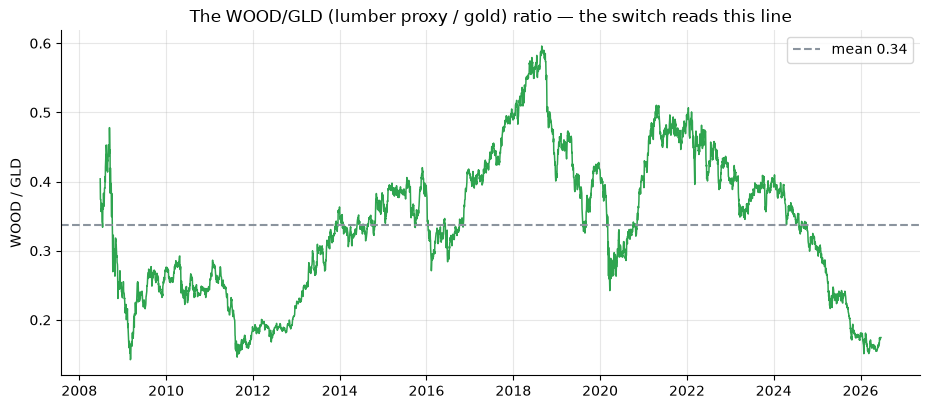

ratio range: 0.142 -> 0.596


In [2]:
if HAVE_REAL:
    ratio = st.lumber_gold_ratio(F)
    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    ax.plot(ratio.index, ratio.values, c=GREEN, lw=1.1)
    ax.axhline(ratio.mean(), ls='--', c=GREY, label=f'mean {ratio.mean():.2f}')
    ax.set_title('The WOOD/GLD (lumber proxy / gold) ratio — the switch reads this line')
    ax.set_ylabel('WOOD / GLD'); ax.legend()
    plt.tight_layout(); plt.show()
    print('ratio range:', round(float(ratio.min()),3), '->', round(float(ratio.max()),3))
else:
    print('no cache — see docs/results.md for the frozen numbers')

It heaved around — high in the 2008-era commodity world, crushed afterwards. The switch flips you into stocks when it's stretched high. Does that timing help? Let's race it.

**The race.** Risk-adjusted score (Sharpe, above cash) for the lumber/gold switch next to the three things you'd do instead. Higher is better.

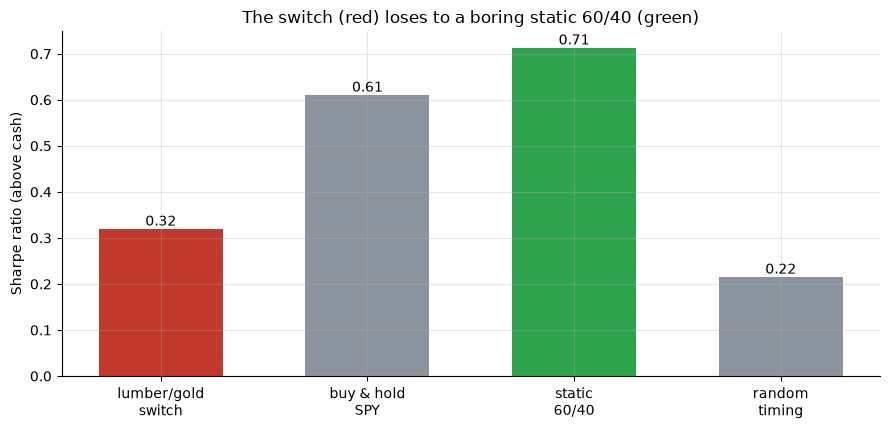

switch Sharpe 0.32 vs static 60/40 0.71


In [3]:
labels = ['lumber/gold\nswitch', 'buy & hold\nSPY', 'static\n60/40', 'random\ntiming']
if HAVE_REAL:
    sh = [RACE['switch']['sharpe_excess'], RACE['buy_hold']['sharpe_excess'],
          RACE['blend_6040']['sharpe_excess'], RACE['random']['sharpe_excess']]
else:
    sh = [R['switch'][1], R['buy_hold'][1], R['blend_6040'][1], R['random'][1]]
cols = [RED, GREY, GREEN, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, sh, color=cols, width=.6)
for i,v in enumerate(sh): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe ratio (above cash)')
ax.set_title('The switch (red) loses to a boring static 60/40 (green)')
plt.tight_layout(); plt.show()
print('switch Sharpe', round(sh[0],2), 'vs static 60/40', round(sh[2],2))

There it is. The lumber/gold switch scores **0.32**; a set-and-forget **60/40** scores **0.71** — and does it with a far gentler worst-case fall. All the clever flipping *under-performs* the laziest possible mix.

**But does the timing do anything at all?** The fairest test: a **coin** that holds bonds on the *same number* of random days. If the ratio sees regimes, the real switch pulls ahead. Here's their growth side by side.

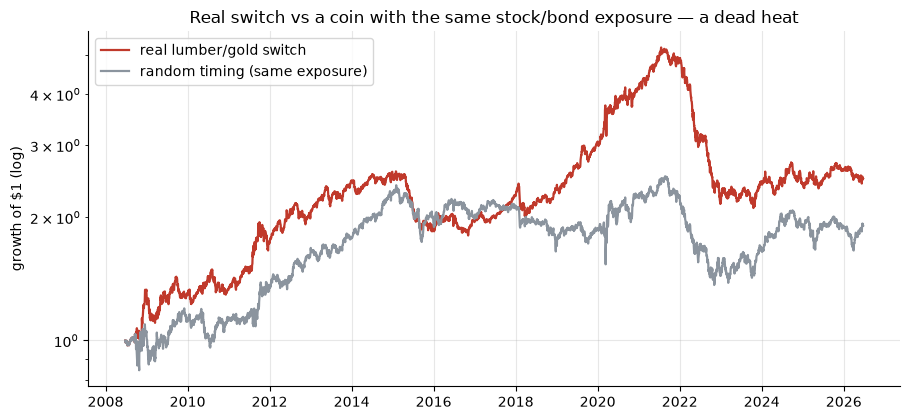

switch ends at 2.49 | random ends at 1.91


In [4]:
if HAVE_REAL:
    pos = st.switch_positions(F, lookback=60, enter_z=0.0)
    rnd = st.random_positions(pos, seed=388)
    sw = st.book_returns(F, pos, cost_bps=5.0)['r_net']
    rb = st.book_returns(F, rnd, cost_bps=5.0)['r_net']
    nav_s = (1+sw).cumprod(); nav_r = (1+rb).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.3))
    ax.plot(nav_s.index, nav_s.values, c=RED, lw=1.6, label='real lumber/gold switch')
    ax.plot(nav_r.index, nav_r.values, c=GREY, lw=1.6, label='random timing (same exposure)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('Real switch vs a coin with the same stock/bond exposure — a dead heat')
    ax.legend(); plt.tight_layout(); plt.show()
    print('switch ends at', round(float(nav_s.iloc[-1]),2), '| random ends at', round(float(nav_r.iloc[-1]),2))
else:
    print('no cache — frozen: switch Sharpe', R['switch'][1], 'vs random', R['random'][1])

The two lines tangle together. The head-to-head *t*-stat is **+0.25** — a statistical tie. In plain words: **the lumber/gold ratio's "timing" is no better than choosing your bond days at random.** The story isn't adding information.

## 5 · The verdict

- **Signal — None.** The switch's Sharpe (**0.32**) loses to a static 60/40 (**0.71**) and *ties* a same-exposure coin (*t* = +0.25). There's no timing edge.
- **Tradability — Mirage.** ~**609 flips** in 18 years for a book that under-performs the mix and falls **60%** at its worst — nothing to deploy.
- **Beats 60/40? — Busted.** The whole pitch is that the *timing* beats the boring blend. It doesn't — the head-to-head is *negative*, and no setting flips it positive.

## 6 · Could you actually trade it? — count the flips and the falls

Forget Sharpe for a second. A *defensive* switch is supposed to protect you in crashes. So how deep does each book fall at its worst — and how often does the switch make you trade?

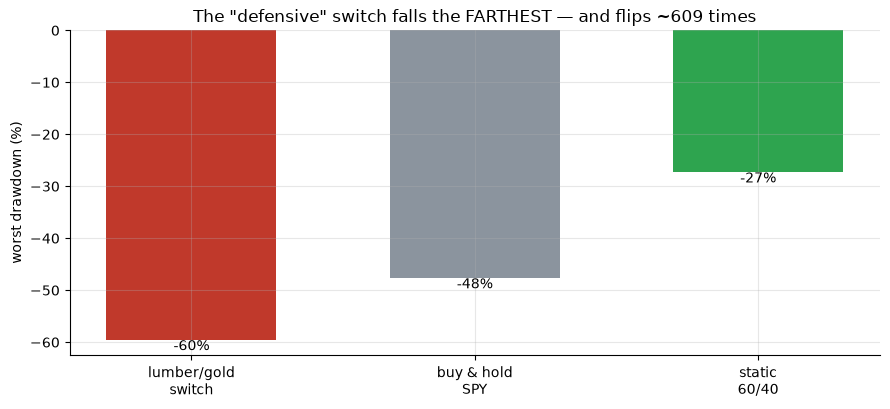

609 whole-book rotations in 18 years; switch worst fall -60% vs 60/40 -27%


In [5]:
labels = ['lumber/gold\nswitch', 'buy & hold\nSPY', 'static\n60/40']
if HAVE_REAL:
    dd = [RACE['switch']['max_dd']*100, RACE['buy_hold']['max_dd']*100, RACE['blend_6040']['max_dd']*100]
    nsw = RACE['n_switches']
else:
    dd = [R['switch'][2], R['buy_hold'][2], R['blend_6040'][2]]; nsw = R['n_switches']
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(labels, dd, color=[RED, GREY, GREEN], width=.6)
for i,v in enumerate(dd): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='top')
ax.set_ylabel('worst drawdown (%)')
ax.set_title(f'The "defensive" switch falls the FARTHEST — and flips ~{nsw} times')
plt.tight_layout(); plt.show()
print(f'{nsw} whole-book rotations in 18 years; switch worst fall {dd[0]:.0f}% vs 60/40 {dd[2]:.0f}%')

The punchline writes itself: the supposedly *defensive* lumber/gold switch has the **deepest** drawdown of the three (**60%**, vs the 60/40's **27%**) — because the ratio kept it in bonds during stock rallies and in stocks during routs. And it cost you ~**609 trades** to get there. A defensive switch that falls farther than the thing it's defending against is not a strategy — it's a story with a trading bill.

## 7 · Going further 🚪

- **The cousins.** [Study 305 — Gold-Oil-Ratio](../../305-gold-oil-ratio/) and [Study 85 — Dr Copper](../../85-dr-copper/) test the same "a cyclical commodity leads the economy" hope. [Study 113 — Gold-Silver-Ratio](../../113-gold-silver-ratio/) is the within-metals version.
- **The yardstick.** [Study 144 — Permanent-Portfolio](../../144-permanent-portfolio/) is the passive static-mix family any *timing* rule has to beat — and this one doesn't.
- **Build your own.** Swap WOOD for the (short) `LBR` lumber future or a copper/gold ratio and re-run the race — the proxy changes, the timing problem doesn't.

*Think the lumber/gold switch beats 60/40 by more than luck? Build the switch, race it against the static blend **and** a same-exposure coin, and show it landing **ahead of both** — then we'll talk.*